# CLT averaging of Pareto observations: grid and bootstrap filters

The archived Pareto stream is compared with the exact filter and with two implementations of the Gaussian block approximation: the saved grid filter and a bootstrap particle filter. For every archived block size, the particle filter uses the stored block sums directly and sets its step length to the block size.


In [1]:
import _bootstrap  # noqa: F401

from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from discretized_filter.config import set_config
from discretized_filter.core.particle_filter import ParticleFilter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = Path.cwd().resolve()
if not (ROOT / 'saved_path_clt_averaging' / 'comparison.npz').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'saved_path_clt_averaging'
assert (DATA_DIR / 'comparison.npz').exists(), 'Run from the repository root or notebooks/'

with np.load(DATA_DIR / 'comparison.npz', allow_pickle=False) as archive:
    data = {name: archive[name] for name in archive.files}

cfg = set_config(DATA_DIR / 'config_clt.py')

N_PARTICLES = 4000
PF_SEED = 20260903
RESAMPLE_THRESHOLD = 0.5

theta, y, jump_times = data['theta'], data['y'], data['t']
obs = data['obs'][:, 0]
ns = [int(n) for n in data['ns']]
n_exact = int(data['n_exact'])
ht_exact = float(data['ht_exact'])
t_exact = data['t_net_exact']
th_exact = data['theta_est_exact']
y_exact = data['y_est_exact']

n_colors = cm.viridis(np.linspace(0.15, 0.9, len(ns)))
n_color = dict(zip(ns, n_colors))

print(f'Block sizes ns = {ns}')
print(f'Latent path: {len(theta)} states/segments; {n_exact} exact observations '
      f'(h_t={ht_exact:g}); horizon {t_exact[-1] / 3600:.3f} h.')
print(f'Exact filter estimates: {th_exact.shape}')
for n in ns:
    th_n = data[f'theta_est_clt_n{n}']
    print(f'  n={n:>4}: {th_n.shape[0]} points on the block grid '
          f'(t_net_n{n}[-1]={data[f"t_net_n{n}"][-1]:.0f})')


Block sizes ns = [10, 20, 50]
Latent path: 21 states/segments; 86300 exact observations (h_t=1); horizon 23.972 h.
Exact filter estimates: (86301, 4)
  n=  10: 8631 points on the block grid (t_net_n10[-1]=86300)
  n=  20: 4316 points on the block grid (t_net_n20[-1]=86300)
  n=  50: 1727 points on the block grid (t_net_n50[-1]=86300)


## Integrity checks

The archive should be internally consistent: for every $n$, the block observations must equal non-overlapping sums of the exact ($h_t=1$) observation stream, and the block grid / estimate arrays must have matching lengths. The exact filter's own arrays must also be consistent with $h_t=1$ over the same horizon.

In [2]:
print('Integrity checks')
for n in ns:
    obs_n = data[f'obs_n{n}'][:, 0]
    expected = obs[:n_exact].reshape(-1, n).sum(axis=1)
    assert obs_n.shape == expected.shape
    assert np.allclose(obs_n, expected)

    t_net_n = data[f't_net_n{n}']
    th_n = data[f'theta_est_clt_n{n}']
    y_n = data[f'y_est_clt_n{n}']
    n_blocks = n_exact // n
    assert t_net_n.shape == (n_blocks + 1,)
    assert th_n.shape == (n_blocks + 1, th_exact.shape[1])
    assert y_n.shape == (n_blocks + 1, y_exact.shape[1])
    print(f'  n={n:>4}: obs_n matches block sums of the exact stream; '
          f'{n_blocks} blocks, grids/estimates consistent (OK)')

assert th_exact.shape[0] == t_exact.shape[0] == n_exact + 1
assert y_exact.shape[0] == n_exact + 1
print(f'  exact filter: {n_exact + 1} points on its own h_t={ht_exact:g} grid (OK)')

Integrity checks
  n=  10: obs_n matches block sums of the exact stream; 8630 blocks, grids/estimates consistent (OK)
  n=  20: obs_n matches block sums of the exact stream; 4315 blocks, grids/estimates consistent (OK)
  n=  50: obs_n matches block sums of the exact stream; 1726 blocks, grids/estimates consistent (OK)
  exact filter: 86301 points on its own h_t=1 grid (OK)


## Bootstrap particle filter

Each block size is run separately with 4,000 particles and the fixed seed `PF_SEED`. The archived block sums are passed without rescaling; `ht=n` supplies their integrated conditional mean and variance.


In [3]:
def run_particle_filter(block_size):
    pf = ParticleFilter(
        cfg.p0,
        cfg.Lambda,
        cfg.get_y,
        cfg.y_intervals,
        cfg.channels,
        ht=float(block_size),
        n_particles=N_PARTICLES,
        resample_threshold=RESAMPLE_THRESHOLD,
        seed=PF_SEED,
    )
    estimate = pf.estimate()
    theta_est = [estimate[0]]
    y_est = [estimate[1]]
    ess = [pf.ess]
    for block_obs in data[f'obs_n{block_size}']:
        pf.update(block_obs)
        estimate = pf.estimate()
        theta_est.append(estimate[0])
        y_est.append(estimate[1])
        ess.append(pf.ess)
    return np.asarray(theta_est), np.asarray(y_est), np.asarray(ess)


pf_runs = {}
for n in ns:
    started = time.perf_counter()
    th_pf, y_pf, ess_pf = run_particle_filter(n)
    elapsed = time.perf_counter() - started

    target_theta_shape = data[f'theta_est_clt_n{n}'].shape
    target_y_shape = data[f'y_est_clt_n{n}'].shape
    n_rows = len(data[f'obs_n{n}']) + 1
    assert th_pf.shape == target_theta_shape == (n_rows, cfg.N)
    assert y_pf.shape == target_y_shape == (n_rows, cfg.M)
    assert ess_pf.shape == (n_rows,)
    assert data[f't_net_n{n}'].shape == (n_rows,)
    assert np.isfinite(th_pf).all() and np.isfinite(y_pf).all()
    assert np.isfinite(ess_pf).all()
    assert np.all(th_pf >= -1e-12)
    assert np.allclose(th_pf.sum(axis=1), 1.0, atol=1e-10)
    assert np.all((ess_pf > 0.0) & (ess_pf <= N_PARTICLES + 1e-9))

    pf_runs[n] = {'theta': th_pf, 'y': y_pf, 'ess': ess_pf, 'time': elapsed}
    print(f'n={n:>4}: {elapsed:6.2f} s, ESS min/median/final = '
          f'{ess_pf.min():.0f}/{np.median(ess_pf):.0f}/{ess_pf[-1]:.0f}')


n=  10:  14.46 s, ESS min/median/final = 1/3090/3494


n=  20:   6.61 s, ESS min/median/final = 1/3051/3483


n=  50:   4.06 s, ESS min/median/final = 1/2928/3490


## Does aggregation make the Pareto noise more Gaussian?

For the single-step exact stream, each observation is standardized by its conditional mean $Y_1+Y_2$ and conditional standard deviation $Y_2/\sqrt{12}$, evaluated on the true path at the observation time (`path_at`, same convention as `pareto_precomputed_comparison.ipynb`). For a block of $n$ observations, conditional means and variances are summed over the block before standardization -- this is exactly the moment-matching used by the CLT likelihood. The reference curve is $N(0,1)$.

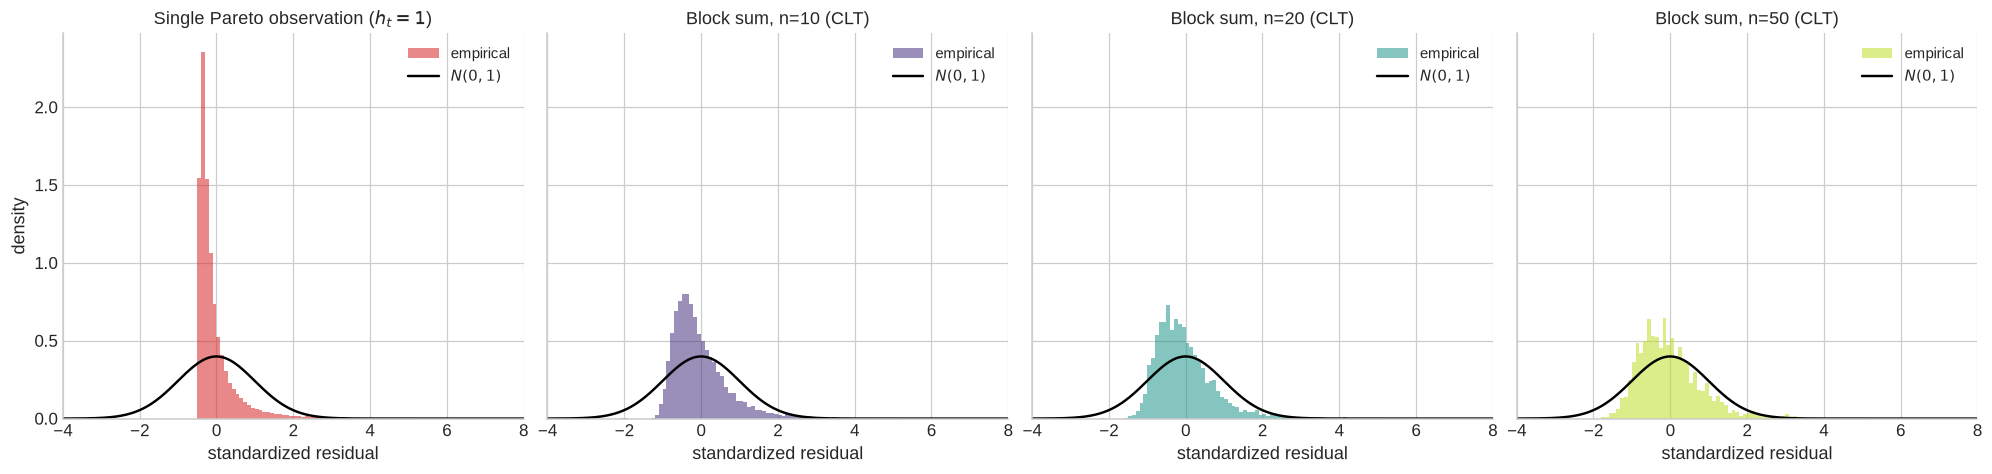

single step : mean= 0.001, std=0.878, skew=12.80, excess kurtosis= 390.7, P(|Z|>3)=1.133%, max=50.76
n=10        : mean= 0.003, std=0.870, skew= 3.90, excess kurtosis=  34.9, P(|Z|>3)=1.124%, max=14.94
n=20        : mean= 0.004, std=0.876, skew= 2.69, excess kurtosis=  15.8, P(|Z|>3)=1.182%, max=9.98
n=50        : mean= 0.007, std=0.897, skew= 1.90, excess kurtosis=   8.3, P(|Z|>3)=1.101%, max=7.34


In [4]:
def path_at(grid):
    # theta[k], y[k] apply from the previous jump through jump_times[k].
    idx = np.searchsorted(jump_times, grid, side='left')
    return theta[idx], y[idx]

_, y_step = path_at(t_exact[1:])
mu_step = y_step[:, 0] + y_step[:, 1]
var_step = y_step[:, 1] ** 2 / 12.0
z_step = (obs - mu_step) / np.sqrt(var_step)

z_by_n = {
    n: (data[f'obs_n{n}'][:, 0] - mu_step.reshape(-1, n).sum(axis=1))
       / np.sqrt(var_step.reshape(-1, n).sum(axis=1))
    for n in ns
}

all_z = np.concatenate([z_step] + [z_by_n[n] for n in ns])
lo = min(-4.0, float(np.floor(np.percentile(all_z, 0.5))))
hi = max(8.0, float(np.ceil(np.percentile(all_z, 99.5))))
x = np.linspace(lo, hi, 800)
normal_pdf = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
bins = np.linspace(lo, hi, 121)

fig, axes = plt.subplots(1, 1 + len(ns), figsize=(4.5 * (1 + len(ns)), 4.2),
                          sharey=True, layout='constrained')
axes = np.atleast_1d(axes)
panels = [(axes[0], z_step, 'Single Pareto observation ($h_t=1$)', 'tab:red')]
for i, n in enumerate(ns):
    panels.append((axes[i + 1], z_by_n[n], f'Block sum, n={n} (CLT)', n_color[n]))
for ax, values, title, color in panels:
    ax.hist(values, bins=bins, density=True, alpha=.55, color=color, label='empirical')
    ax.plot(x, normal_pdf, color='black', lw=1.6, label='$N(0,1)$')
    ax.set(title=title, xlabel='standardized residual', xlim=(lo, hi))
    ax.legend(fontsize=10)
axes[0].set_ylabel('density')
plt.show()

rows = [('single step', z_step)] + [(f'n={n}', z_by_n[n]) for n in ns]
for label, values in rows:
    centered = (values - values.mean()) / values.std()
    skewness = np.mean(centered ** 3)
    excess_kurtosis = np.mean(centered ** 4) - 3
    print(f'{label:12s}: mean={values.mean(): .3f}, std={values.std():.3f}, '
          f'skew={skewness:5.2f}, excess kurtosis={excess_kurtosis:6.1f}, '
          f'P(|Z|>3)={np.mean(np.abs(values) > 3):.3%}, max={values.max():.2f}')

## State-probability estimates

The exact filter is shown on its own $h_t=1$ grid; each CLT filter is shown on its own block grid. The black step line marks the true latent state. Colors for $n$ come from one sequential palette (viridis, lighter for smaller $n$), so the ordering across block sizes can be read directly off the plot; the exact filter is always `tab:red`.

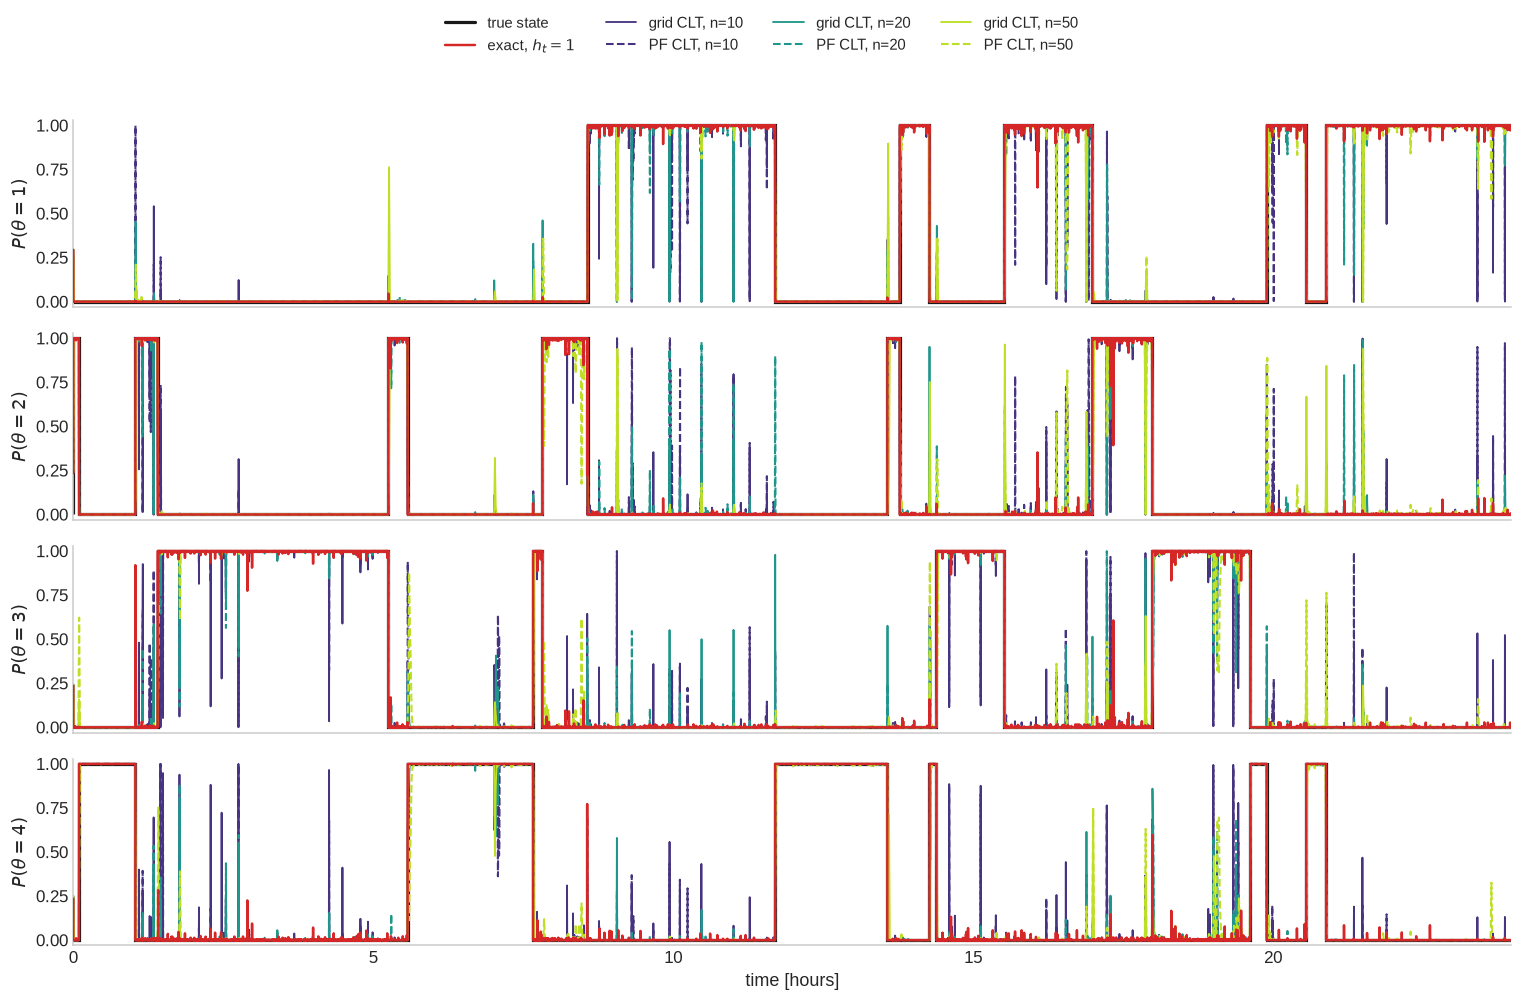

In [5]:
starts = np.r_[0.0, jump_times[:-1]] / 3600
ends = jump_times / 3600
segment_edges = np.r_[starts, ends[-1]]

n_states = th_exact.shape[1]
fig, axes = plt.subplots(n_states, 1, figsize=(14, 2.3 * n_states), sharex=True)
axes = np.atleast_1d(axes)
for state, ax in enumerate(axes):
    ax.stairs(theta == state, segment_edges, color='black', lw=2.1, alpha=.9, zorder=2,
              label='true state')
    ax.plot(t_exact / 3600, th_exact[:, state], color='tab:red', lw=1.6, zorder=4,
            label=f'exact, $h_t={ht_exact:g}$')
    for n in ns:
        t_n = data[f't_net_n{n}'] / 3600
        ax.plot(t_n, data[f'theta_est_clt_n{n}'][:, state], color=n_color[n],
                ls='-', lw=1.2, zorder=3, label=f'grid CLT, n={n}')
        ax.plot(t_n, pf_runs[n]['theta'][:, state], color=n_color[n],
                ls='--', lw=1.35, zorder=3, label=f'PF CLT, n={n}')
    ax.set(ylabel=fr'$P(\theta={state + 1})$', ylim=(-.03, 1.03))
    ax.grid()
axes[-1].set(xlabel='time [hours]', xlim=(0, t_exact[-1] / 3600))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4,
           frameon=False, bbox_to_anchor=(.5, .995))
fig.tight_layout(rect=(0, 0, 1, .90))
plt.show()


## Continuous-state estimates

Same layout for $Y_1$ and $Y_2$. The black step line marks the true piecewise-constant path.

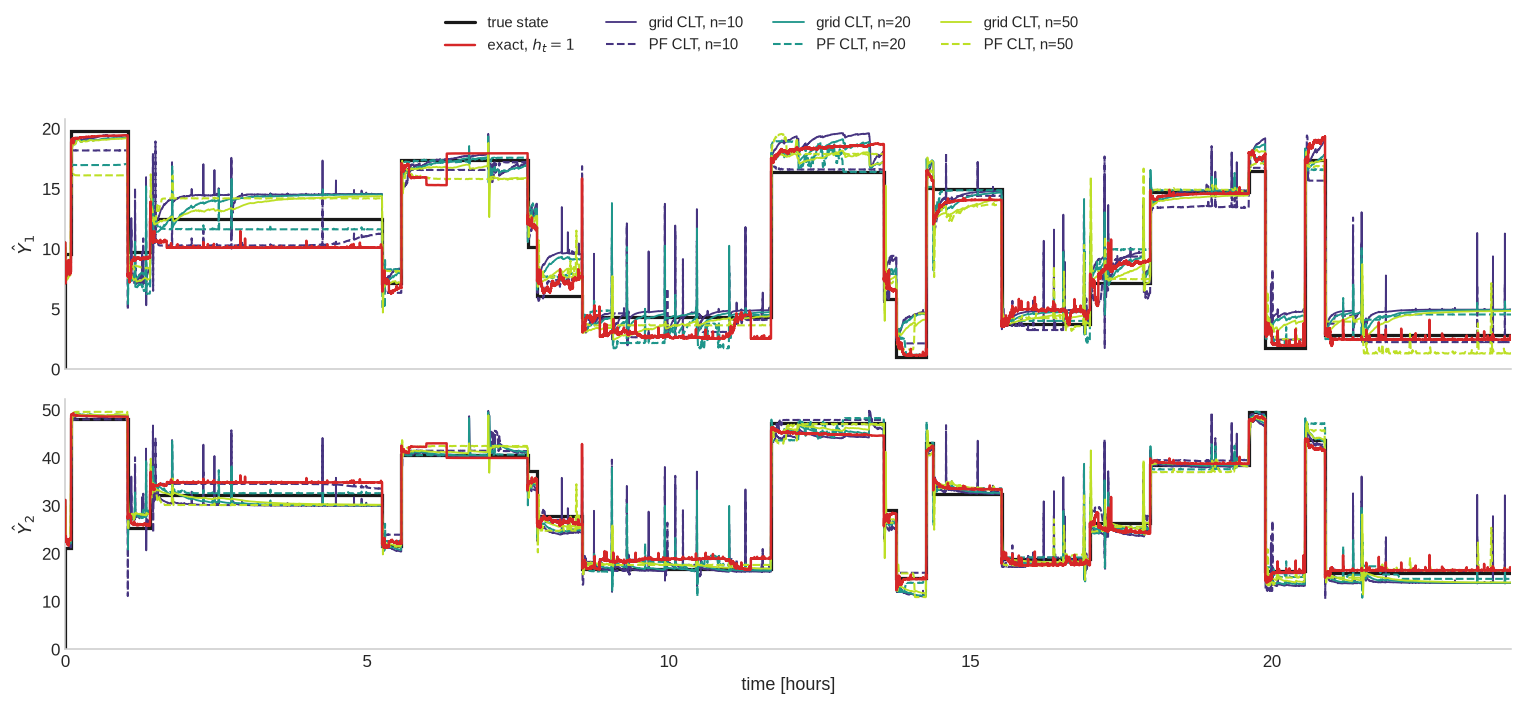

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True)
for component, ax in enumerate(axes):
    ax.stairs(y[:, component], segment_edges, color='black', lw=2.1, alpha=.9, zorder=2,
              label='true state')
    ax.plot(t_exact / 3600, y_exact[:, component], color='tab:red', lw=1.6, zorder=4,
            label=f'exact, $h_t={ht_exact:g}$')
    for n in ns:
        t_n = data[f't_net_n{n}'] / 3600
        ax.plot(t_n, data[f'y_est_clt_n{n}'][:, component], color=n_color[n],
                ls='-', lw=1.2, zorder=3, label=f'grid CLT, n={n}')
        ax.plot(t_n, pf_runs[n]['y'][:, component], color=n_color[n],
                ls='--', lw=1.35, zorder=3, label=f'PF CLT, n={n}')
    ax.set_ylabel(fr'$\hat Y_{component + 1}$')
    ax.grid()
axes[-1].set(xlabel='time [hours]', xlim=(0, t_exact[-1] / 3600))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4,
           frameon=False, bbox_to_anchor=(.5, .995))
fig.tight_layout(rect=(0, 0, 1, .86))
plt.show()


## Accuracy against the true path

For each block size $n$, the CLT estimate is compared against the true path on the filter's own block grid. The $\theta$ RMSE is over all four one-hot components. The exact filter's RMSE on its own $h_t=1$ grid is drawn as a horizontal reference line -- the accuracy available if one could afford to filter every raw observation.

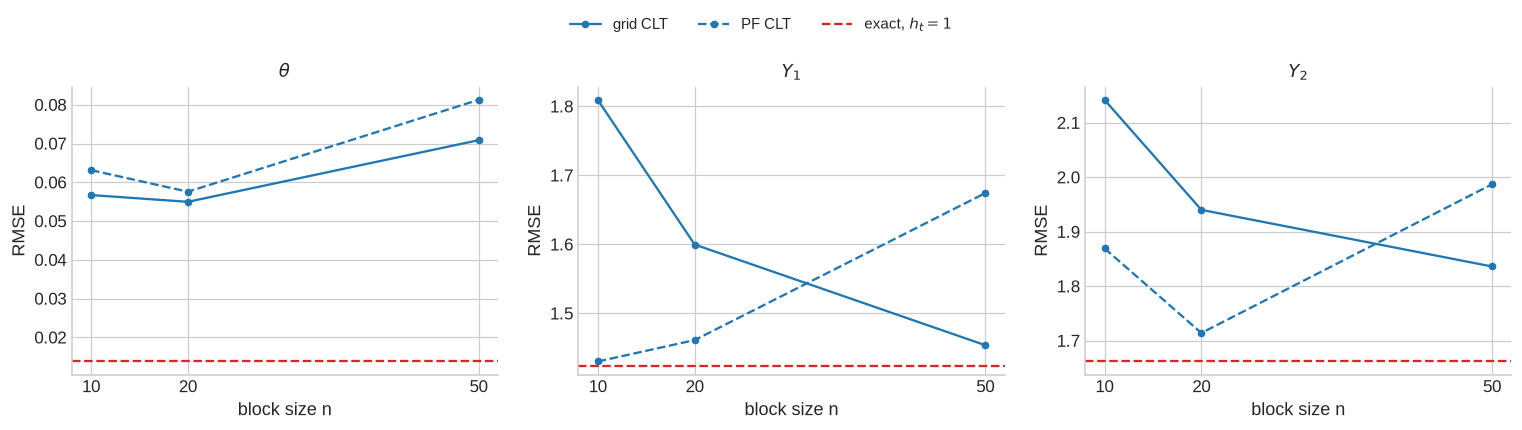

filter              RMSE theta   RMSE Y1   RMSE Y2
--------------------------------------------------
exact, h_t=1            0.0138    1.4238    1.6619
grid CLT, n=10          0.0567    1.8094    2.1420
PF CLT, n=10            0.0631    1.4303    1.8695
grid CLT, n=20          0.0550    1.5997    1.9401
PF CLT, n=20            0.0576    1.4613    1.7142
grid CLT, n=50          0.0709    1.4539    1.8362
PF CLT, n=50            0.0813    1.6743    1.9870


In [7]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

n_states = th_exact.shape[1]

true_state_exact, true_y_exact = path_at(t_exact)
true_onehot_exact = np.eye(n_states)[true_state_exact]
rmse_exact = {
    'theta': rmse(th_exact, true_onehot_exact),
    'Y1': rmse(y_exact[:, 0], true_y_exact[:, 0]),
    'Y2': rmse(y_exact[:, 1], true_y_exact[:, 1]),
}

rmse_vs_truth = {}
for n in ns:
    t_net_n = data[f't_net_n{n}']
    true_state_n, true_y_n = path_at(t_net_n)
    true_onehot_n = np.eye(n_states)[true_state_n]
    rmse_vs_truth[n] = {}
    for method, th_n, y_n in [
        ('grid', data[f'theta_est_clt_n{n}'], data[f'y_est_clt_n{n}']),
        ('PF', pf_runs[n]['theta'], pf_runs[n]['y']),
    ]:
        rmse_vs_truth[n][method] = {
            'theta': rmse(th_n, true_onehot_n),
            'Y1': rmse(y_n[:, 0], true_y_n[:, 0]),
            'Y2': rmse(y_n[:, 1], true_y_n[:, 1]),
        }

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(axes, ['theta', 'Y1', 'Y2'], [r'$\theta$', r'$Y_1$', r'$Y_2$']):
    ax.plot(ns, [rmse_vs_truth[n]['grid'][key] for n in ns], 'o-', color='tab:blue',
            lw=1.5, ms=4, label='grid CLT')
    ax.plot(ns, [rmse_vs_truth[n]['PF'][key] for n in ns], 'o--', color='tab:blue',
            lw=1.5, ms=4, label='PF CLT')
    ax.axhline(rmse_exact[key], color='tab:red', ls='--', lw=1.5,
               label=f'exact, $h_t={ht_exact:g}$')
    ax.set(xlabel='block size n', ylabel='RMSE', title=title)
    ax.set_xticks(ns)
    ax.set_xticklabels([str(n) for n in ns])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(.5, .99))
fig.tight_layout(rect=(0, 0, 1, .90))
plt.show()

head = f'{"filter":<18}{"RMSE theta":>12}{"RMSE Y1":>10}{"RMSE Y2":>10}'
print(head)
print('-' * len(head))
print(f'{"exact, h_t=" + f"{ht_exact:g}":<18}{rmse_exact["theta"]:12.4f}'
      f'{rmse_exact["Y1"]:10.4f}{rmse_exact["Y2"]:10.4f}')
for n in ns:
    for method, label in [('grid', 'grid CLT'), ('PF', 'PF CLT')]:
        r = rmse_vs_truth[n][method]
        print(f'{label + ", n=" + str(n):<18}{r["theta"]:12.4f}'
              f'{r["Y1"]:10.4f}{r["Y2"]:10.4f}')


## Direct exact-versus-CLT discrepancy

Rather than compare each filter to the (in practice unknown) truth, this section thins the exact filter to each block grid (`theta_est_exact[::n]`) and measures how far the CLT estimate departs from the exact one directly -- this isolates the Gaussian-approximation error from estimation error against the latent path. The heatmap of the signed difference is shown for the *largest* $n$ in the sweep, i.e. the coarsest and most stressed approximation.

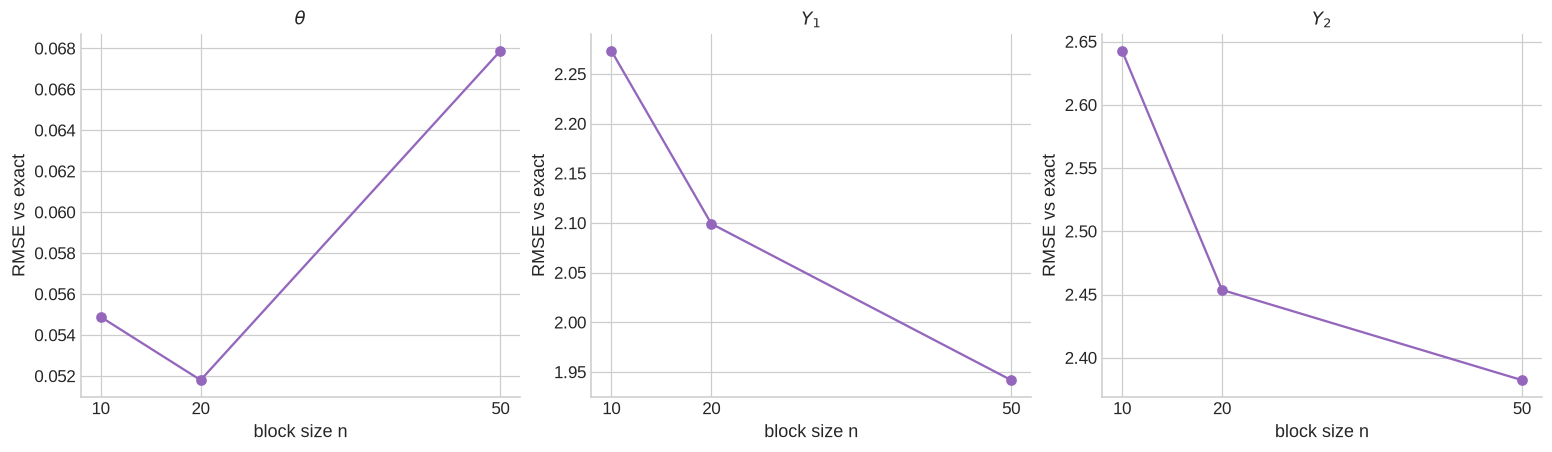

     n  RMSE theta   RMSE Y1   RMSE Y2
--------------------------------------
    10      0.0549    2.2733    2.6428
    20      0.0518    2.0993    2.4537
    50      0.0679    1.9419    2.3823


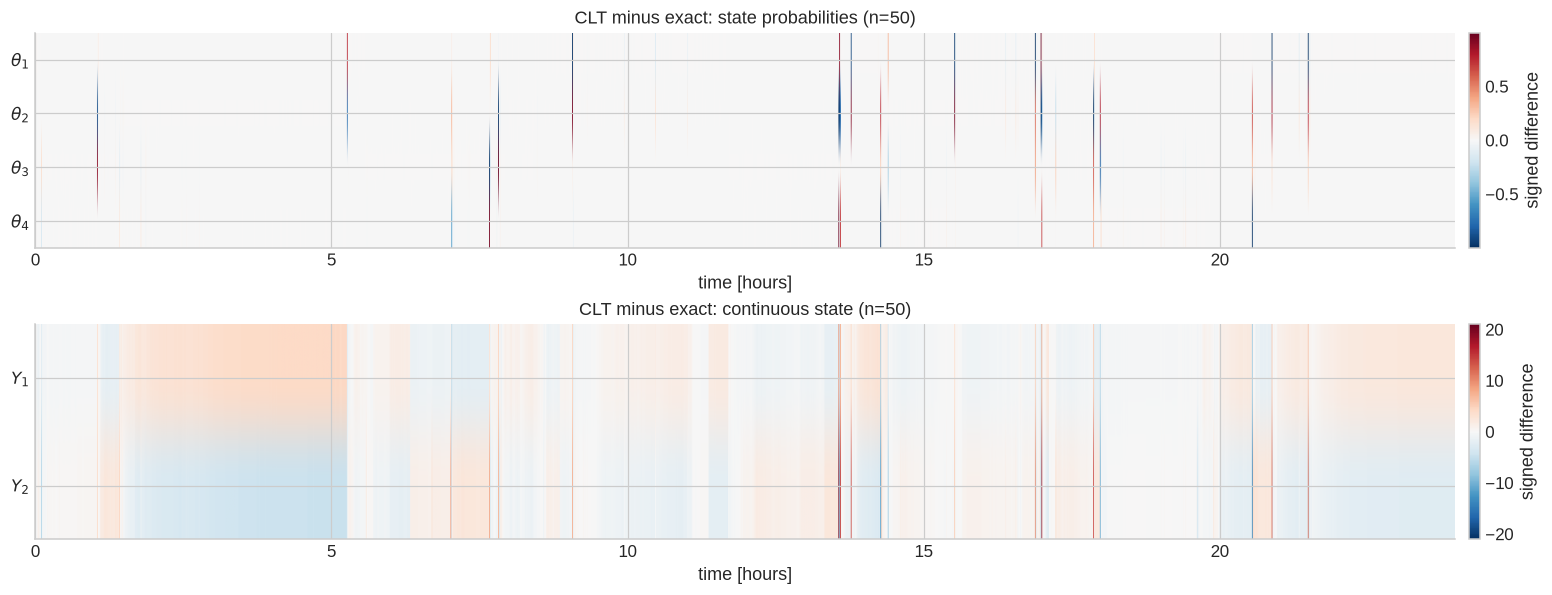

Max |CLT - exact| for theta (n=50): 0.9999
Max |CLT - exact| for Y (n=50):     21.0459

PF versus grid CLT
     n  RMSE theta   RMSE Y1   RMSE Y2   max theta     max Y
------------------------------------------------------------
    10      0.0423    2.2250    2.5216      1.0000   15.2560
    20      0.0313    1.5048    1.4990      0.8849    9.8535
    50      0.0568    1.3756    1.4236      0.8869   14.8287


In [8]:
rmse_vs_exact = {}
thinned = {}
for n in ns:
    th_thin = th_exact[::n]
    y_thin = y_exact[::n]
    th_n = data[f'theta_est_clt_n{n}']
    y_n = data[f'y_est_clt_n{n}']
    m = min(th_thin.shape[0], th_n.shape[0])
    thinned[n] = (th_thin[:m], y_thin[:m], th_n[:m], y_n[:m])
    rmse_vs_exact[n] = {
        'theta': rmse(th_thin[:m], th_n[:m]),
        'Y1': rmse(y_thin[:m, 0], y_n[:m, 0]),
        'Y2': rmse(y_thin[:m, 1], y_n[:m, 1]),
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
for ax, key, title in zip(axes, ['theta', 'Y1', 'Y2'], [r'$\theta$', r'$Y_1$', r'$Y_2$']):
    ax.plot(ns, [rmse_vs_exact[n][key] for n in ns], 'o-', color='tab:purple')
    ax.set(xlabel='block size n', ylabel='RMSE vs exact', title=title)
    ax.set_xticks(ns)
    ax.set_xticklabels([str(n) for n in ns])
plt.show()

head = f'{"n":>6}{"RMSE theta":>12}{"RMSE Y1":>10}{"RMSE Y2":>10}'
print(head)
print('-' * len(head))
for n in ns:
    r = rmse_vs_exact[n]
    print(f'{n:>6}{r["theta"]:12.4f}{r["Y1"]:10.4f}{r["Y2"]:10.4f}')

n_max = max(ns)
th_thin, y_thin, th_n, y_n = thinned[n_max]
t_net_max = data[f't_net_n{n_max}'][:th_n.shape[0]]
theta_diff = (th_n - th_thin).T
y_diff = (y_n - y_thin).T
fig, axes = plt.subplots(2, 1, figsize=(14, 5.3), layout='constrained')
for ax, difference, labels, title in [
    (axes[0], theta_diff, [fr'$\theta_{i + 1}$' for i in range(theta_diff.shape[0])],
     f'CLT minus exact: state probabilities (n={n_max})'),
    (axes[1], y_diff, [r'$Y_1$', r'$Y_2$'],
     f'CLT minus exact: continuous state (n={n_max})'),
]:
    limit = np.max(np.abs(difference)) or 1.0
    image = ax.imshow(difference, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit,
                       extent=[0, t_net_max[-1] / 3600, difference.shape[0] - .5, -.5])
    ax.set(yticks=np.arange(len(labels)), yticklabels=labels, xlabel='time [hours]', title=title)
    fig.colorbar(image, ax=ax, pad=.01, label='signed difference')
plt.show()

print(f'Max |CLT - exact| for theta (n={n_max}): {np.max(np.abs(theta_diff)):.4f}')
print(f'Max |CLT - exact| for Y (n={n_max}):     {np.max(np.abs(y_diff)):.4f}')

pf_vs_grid = {}
for n in ns:
    th_grid = data[f'theta_est_clt_n{n}']
    y_grid = data[f'y_est_clt_n{n}']
    th_pf = pf_runs[n]['theta']
    y_pf = pf_runs[n]['y']
    pf_vs_grid[n] = {
        'theta': rmse(th_pf, th_grid),
        'Y1': rmse(y_pf[:, 0], y_grid[:, 0]),
        'Y2': rmse(y_pf[:, 1], y_grid[:, 1]),
        'max_theta': float(np.max(np.abs(th_pf - th_grid))),
        'max_Y': float(np.max(np.abs(y_pf - y_grid))),
    }

print('\nPF versus grid CLT')
head = f'{"n":>6}{"RMSE theta":>12}{"RMSE Y1":>10}{"RMSE Y2":>10}{"max theta":>12}{"max Y":>10}'
print(head)
print('-' * len(head))
for n in ns:
    r = pf_vs_grid[n]
    print(f'{n:>6}{r["theta"]:12.4f}{r["Y1"]:10.4f}{r["Y2"]:10.4f}'
          f'{r["max_theta"]:12.4f}{r["max_Y"]:10.4f}')
